## Explainability

In [1]:
import shap
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
import os
import pandas as pd

/home/sssspppuud/Desktop/Project/Code/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-14 14:31:54.857211: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-14 14:31:54.900196: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-14 14:31:56.640175: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may se

In [2]:
sns.set_theme(style="whitegrid", context="poster", palette="bright")
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

In [3]:
PROJECT_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
ARTIFACT_DIR = os.path.join(PROJECT_ROOT, "artifacts")

In [4]:
model = load_model(os.path.join(MODEL_DIR, "model.keras"))
X_test_scaled = np.load(os.path.join(ARTIFACT_DIR,"X_test.npy"))
y_test = np.load(os.path.join(ARTIFACT_DIR,"y_test.npy"))
encoder = joblib.load(os.path.join(ARTIFACT_DIR,"encoder.pkl"))
feature_names = joblib.load(os.path.join(ARTIFACT_DIR,"feature_names.pkl"))
background = np.load(os.path.join(ARTIFACT_DIR,"shap_background.npy"))

2026-03-14 14:31:57.042496: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### SHAP

In [5]:
sample_size = 1000
idx = np.random.choice(len(X_test_scaled), sample_size, replace = False)
X_sample = X_test_scaled[idx]
X_sample.shape

(1000, 45)

In [6]:
explainer = shap.Explainer(model, background)
shap_values = explainer(X_sample)

PermutationExplainer explainer: 1001it [02:34,  6.24it/s]                          


In [7]:
print(f"Model output shape: {model.output_shape}")
print(f"Number of SHAP arrays: {len(shap_values)}")
print(f"Number of labels: {len(encoder.classes_)}")

Model output shape: (None, 5)
Number of SHAP arrays: 1000
Number of labels: 5


/tmp/ipykernel_36853/754362288.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


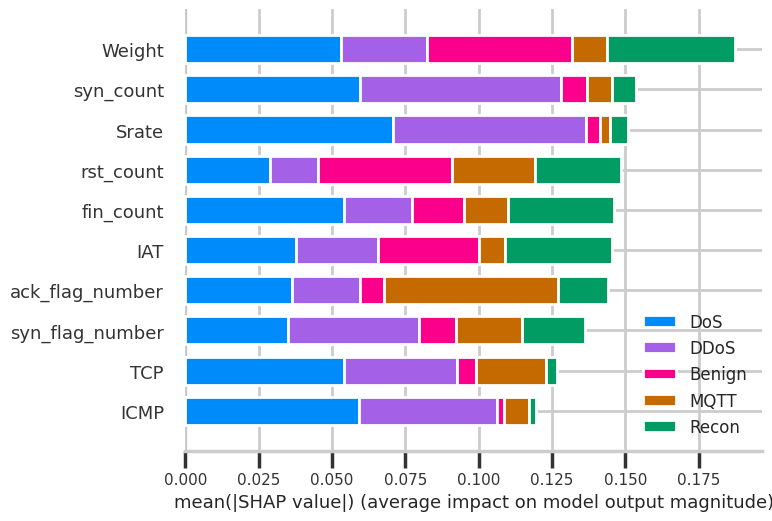

In [8]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names = feature_names,
    plot_type="bar",
    class_names = encoder.classes_,
    max_display=10
)

/tmp/ipykernel_36853/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


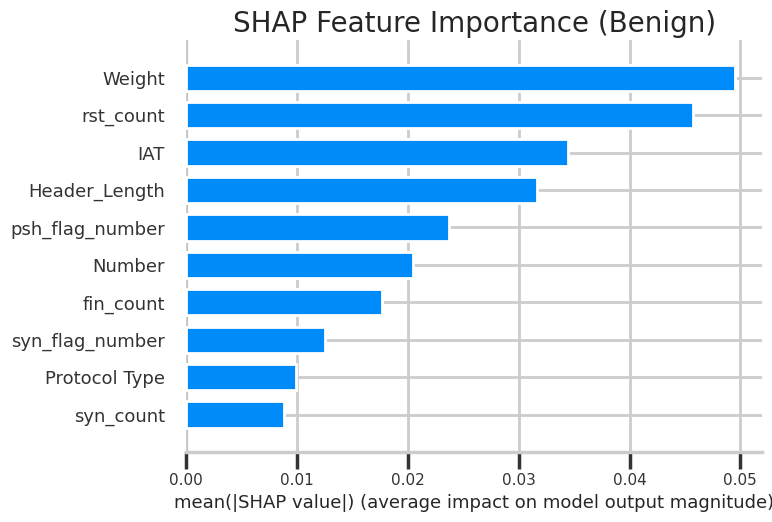

/tmp/ipykernel_36853/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


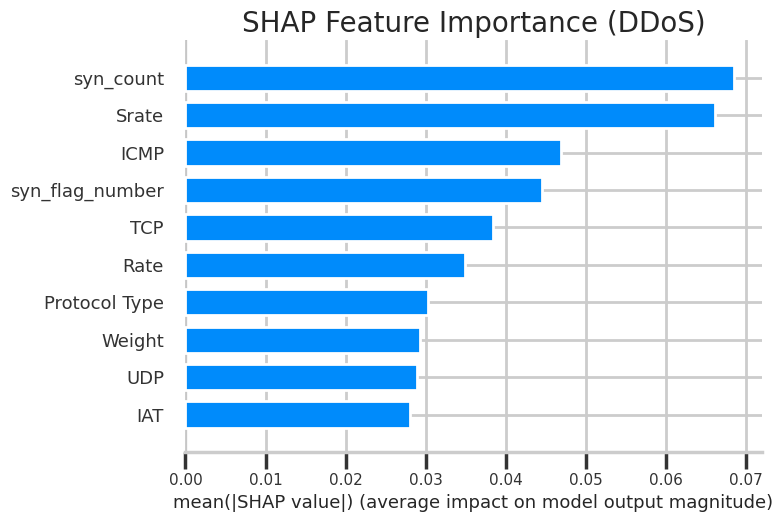

/tmp/ipykernel_36853/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


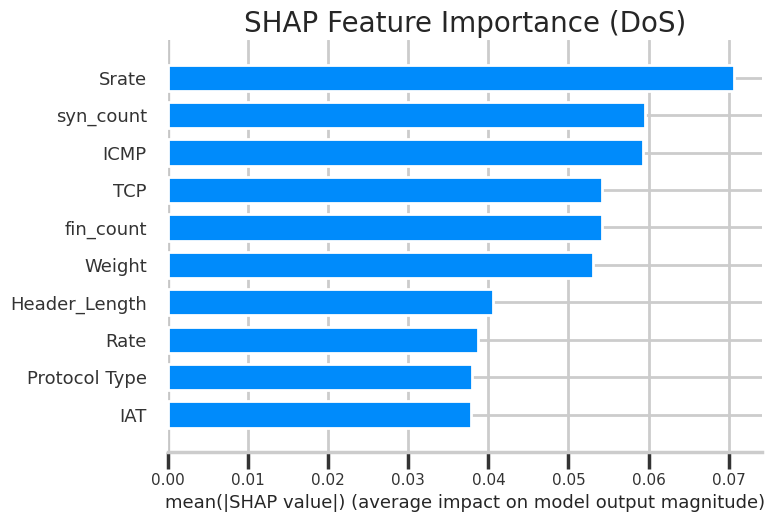

/tmp/ipykernel_36853/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


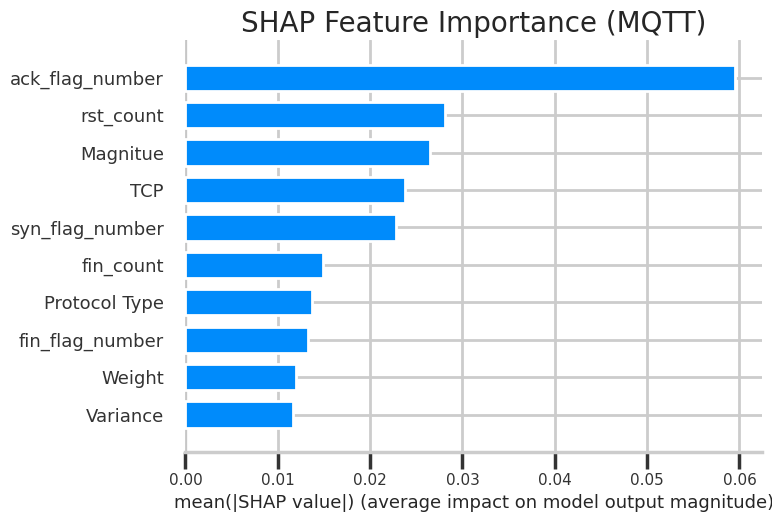

/tmp/ipykernel_36853/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


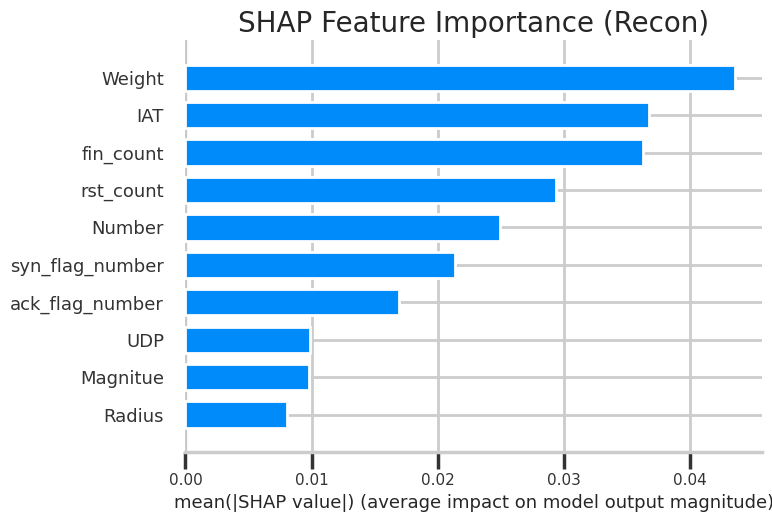

In [9]:
for i, class_label in enumerate(encoder.classes_):
    plt.title(f"SHAP Feature Importance ({class_label})")
    shap.summary_plot(
        shap_values[..., i],
        X_sample,
        feature_names = feature_names,
        plot_type = "bar",
        show = True,
        max_display = 10
    )


/tmp/ipykernel_36853/4042260383.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


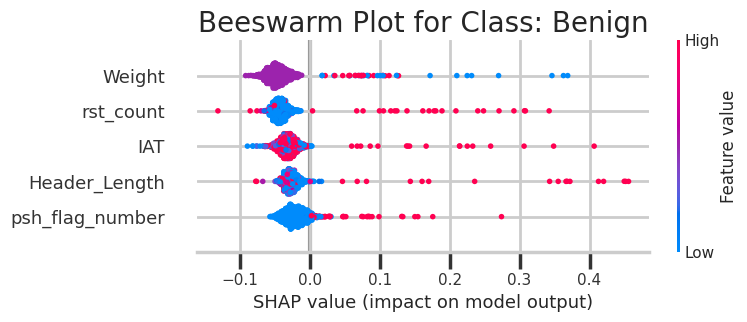

/tmp/ipykernel_36853/4042260383.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


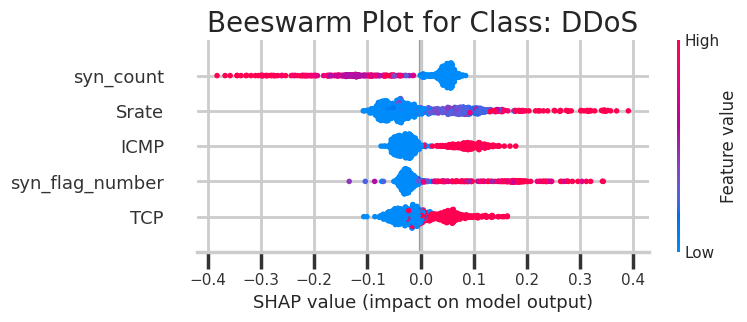

/tmp/ipykernel_36853/4042260383.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


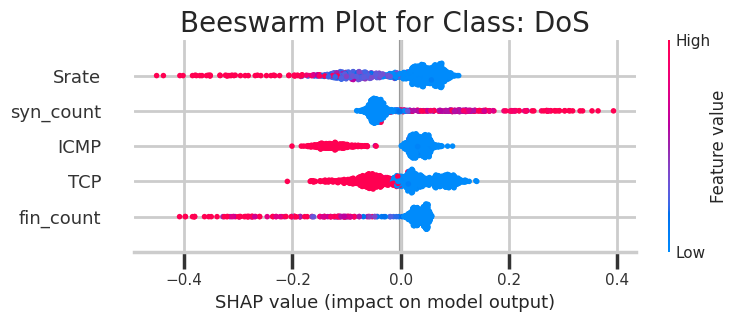

/tmp/ipykernel_36853/4042260383.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


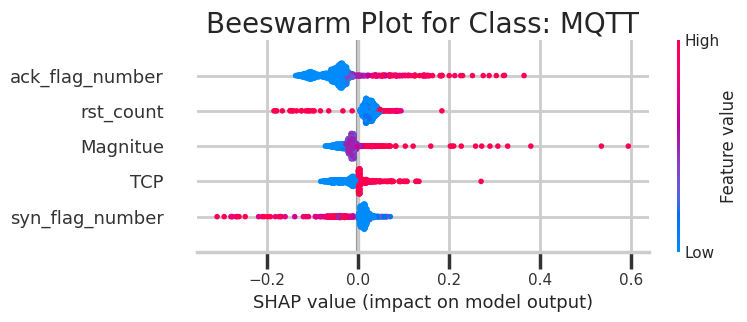

/tmp/ipykernel_36853/4042260383.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


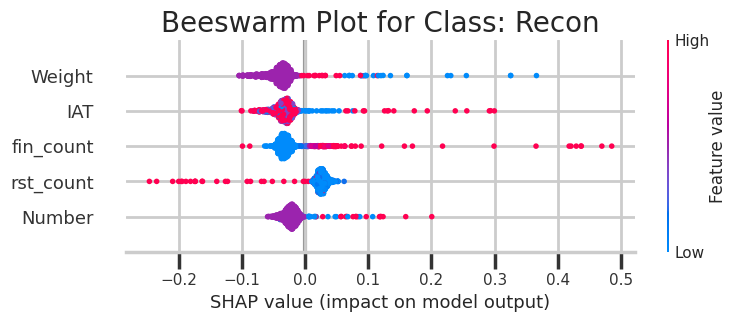

In [10]:
for i, class_label in enumerate(encoder.classes_):
    plt.figure(figsize=(12,10))
    plt.title(f"Beeswarm Plot for Class: {class_label}")
    shap.summary_plot(
        shap_values[..., i],
        X_sample,
        feature_names=feature_names,
        max_display = 5,
        show=False
    )
    plt.show()